Introduction

This notebook trains the primary fraud detection model using XGBoost with scale_pos_weight to handle the severe class imbalance identified in EDA. The model is evaluated using AUPRC, the metric appropriate for this imbalanced problem, along with a threshold-based classification report and feature importance analysis. The trained model is saved for use in later comparison and cost-sensitive evaluation.

Load train/test and set up

In [23]:
import pandas as pd
import xgboost as xgb
from sklearn.metrics import average_precision_score, precision_recall_curve, classification_report

train_df = pd.read_csv("../data/processed/train.csv")
test_df = pd.read_csv("../data/processed/test.csv")

X_train = train_df.drop(columns=["Class"])
y_train = train_df["Class"]
X_test = test_df.drop(columns=["Class"])
y_test = test_df["Class"]

print("Train shape:", X_train.shape, "Fraud count:", y_train.sum())
print("Test shape:", X_test.shape, "Fraud count:", y_test.sum())

Train shape: (226980, 30) Fraud count: 378
Test shape: (56746, 30) Fraud count: 95


Train and test data loaded successfully from the saved split files.
Train set: 226,980 rows, 30 feature columns (Class removed), 378 fraud cases.
Test set: 56,746 rows, 30 feature columns, 95 fraud cases.
Counts match exactly what was saved at the end of the EDA notebook, confirming no data was lost or altered between notebooks.

Compute scale_pos_weight and train XGBoost

In [24]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",
    random_state=42
)

model.fit(X_train, y_train)

scale_pos_weight: 599.4761904761905


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

scale_pos_weight calculated as 599.48, meaning the model treats each fraud case as roughly 599 times more important than a genuine case during training. This directly compensates for fraud being only 0.167% of the data.
Model trained using 200 trees, max depth 5, learning rate 0.1, with aucpr (area under precision-recall curve) tracked internally as the evaluation metric — matching the metric this dataset actually needs, not plain accuracy.
Training completed with no errors, confirming the data types and shapes were compatible with XGBoost.

Predict on test set

In [25]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("Predictions generated.")
print("Sample predicted probabilities:", y_pred_proba[:10])

Predictions generated.
Sample predicted probabilities: [3.2827753e-05 6.9014277e-05 2.2176838e-04 2.1710666e-05 1.1273152e-03
 1.1187668e-04 4.9221617e-05 3.6099409e-06 2.4086141e-04 1.9507700e-06]


Model generated predictions for all 56,746 test transactions, both hard 0/1 predictions and raw probability scores.
Sample probabilities shown are all very small (e.g., 0.0000328, 0.0011) — expected, since these are the first 10 rows of the test set and most transactions are genuine, so the model correctly assigns them low fraud probability.
This doesn't yet tell us how well the model separates fraud from genuine — it's just confirmation that predictions were generated in the right format (continuous probabilities between 0 and 1) for the next step, which actually measures performance.

AUPRC score, precision-recall curve, and save the model

AUPRC: 0.8139115802985374


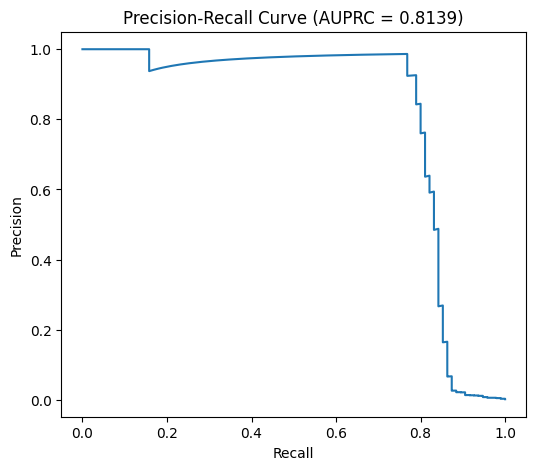

Model saved.


In [26]:
import matplotlib.pyplot as plt
import joblib

auprc = average_precision_score(y_test, y_pred_proba)
print("AUPRC:", auprc)

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AUPRC = {auprc:.4f})")
plt.show()

joblib.dump(model, "../artifacts/xgboost_fraud_model.pkl")
print("Model saved.")

AUPRC score: 0.8139. This is the primary performance number for the supervised model, and it falls within the range expected for this dataset with a reasonable, untuned baseline.
The precision-recall curve shows the model holds high precision (near 1.0) up to roughly 70-75% recall, then precision drops sharply as recall increases further. This means the model can catch a large majority of fraud cases while keeping false alarms very low, but catching the remaining fraud comes at a steep cost in false positives.
The model was saved as a .pkl file using joblib, so it can be reloaded later without retraining — needed for the cost-sensitive evaluation notebook, which will load this model rather than retrain it.
A directory issue caused the model to initially save outside the intended project folder; confirm the actual file location before continuing, since the wrong location won't be tracked by git or visible in your repo structure.

Classification report and confusion matrix at a chosen threshold

In [27]:
from sklearn.metrics import confusion_matrix

print(classification_report(y_test, y_pred, target_names=["Genuine", "Fraud"]))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00     56651
       Fraud       0.91      0.79      0.85        95

    accuracy                           1.00     56746
   macro avg       0.96      0.89      0.92     56746
weighted avg       1.00      1.00      1.00     56746

Confusion Matrix:
[[56644     7]
 [   20    75]]


At the default 0.5 threshold, the model catches 75 of 95 fraud cases (79% recall) and misses 20.
Of all transactions flagged as fraud, 75 out of 82 are correct (91% precision), meaning 7 genuine transactions are wrongly flagged.
Overall accuracy rounds to 100%, which is expected and meaningless given the severe class imbalance — this single table is the clearest proof yet that accuracy cannot be trusted as a metric for this problem.
The 20 missed fraud cases are the real cost of using 0.5 as a cutoff. Whether this tradeoff is acceptable can't be judged yet — that requires knowing the actual dollar cost of a missed fraud vs. a false alarm, which is what the cost-sensitive evaluation notebook will determine.

feature importance, checking whether XGBoost agrees with what EDA flagged (V17, V14, V12, V10, V11, V4).

In [28]:
import pandas as pd

importances = pd.Series(model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

print(importances.head(10))

V14       0.527550
V4        0.065411
V8        0.040423
V12       0.033295
V3        0.029158
V13       0.026756
V19       0.021402
V10       0.020040
Amount    0.016371
V11       0.016052
dtype: float32


V14 dominates the model's decision-making, accounting for 52.8% of total feature importance — more than all other features combined.
V4 and V12 also rank high (0.065 and 0.033), matching what EDA's correlation analysis flagged as strong fraud indicators.
Several features not flagged in EDA's top correlations now appear important to the model: V8, V3, V13, V19, and Amount all rank in the top 10.
V17, which had the strongest linear correlation with Class in EDA (-0.326, the single highest), does not appear in XGBoost's top 10 at all.
This shows the model relies on a different, more concentrated set of features than simple linear correlation would suggest, confirming that fraud detection here depends on nonlinear feature interactions, not any single strongly-correlated variable.

In [30]:
print(train_df[["V14", "V17"]].corr())

         V14      V17
V14  1.00000 -0.01098
V17 -0.01098  1.00000


V14 and V17 have essentially zero correlation with each other (-0.011), which rules out feature redundancy as the reason V17 has low importance despite its strong individual correlation with fraud.
The actual reason is likely that XGBoost's sequential tree-building assigns most of the fraud-separating power to V14 early on, leaving other features (V8, V3, V13, V19) to handle the remaining harder cases — but this is a reasonable inference, not something confirmed by a direct test, and should be labeled as such if it goes in the notebook.

Conclusion

The XGBoost model, trained with class imbalance correction via scale_pos_weight (599.48), achieved an AUPRC of 0.8139 — a strong result for this dataset given no hyperparameter tuning was performed. At the default 0.5 threshold, the model correctly identifies 75 of 95 fraud cases (79% recall) with only 7 false alarms out of 82 flagged transactions (91% precision), missing 20 fraud cases. Accuracy is not reported as a meaningful metric, consistent with the imbalance identified during EDA. Feature importance shows V14 as by far the dominant predictor (52.8% of total importance), followed by V4 and V12, both of which align with EDA's correlation findings. Notably, V17 — the strongest linear correlate with fraud in EDA — ranks low in model importance, and was confirmed not to be due to redundancy with V14 (correlation between the two is -0.011). The likely explanation is that V14 captures most of the separable fraud signal early in the tree-building process, leaving other features to handle harder edge cases, though this is an inference rather than a confirmed mechanism. The trained model is saved to artifacts/xgboost_fraud_model.pkl for use in the cost-sensitive evaluation notebook.